In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings


from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [27]:
warnings.filterwarnings('ignore')

In [28]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-darkgrid')

In [29]:
df = pd.read_csv('../data/processed/cleaned_data.csv',
                 index_col='Date', parse_dates=True)

split_index = int(len(df) * 0.90)
train = df.iloc[:split_index]['hhs_care']
test  = df.iloc[split_index:]['hhs_care']

print(f"Train: {len(train)} rows | {train.index.min().date()} to {train.index.max().date()}")
print(f"Test:  {len(test)} rows  | {test.index.min().date()} to {test.index.max().date()}")

Train: 967 rows | 2023-01-12 to 2025-09-04
Test:  108 rows  | 2025-09-05 to 2025-12-21


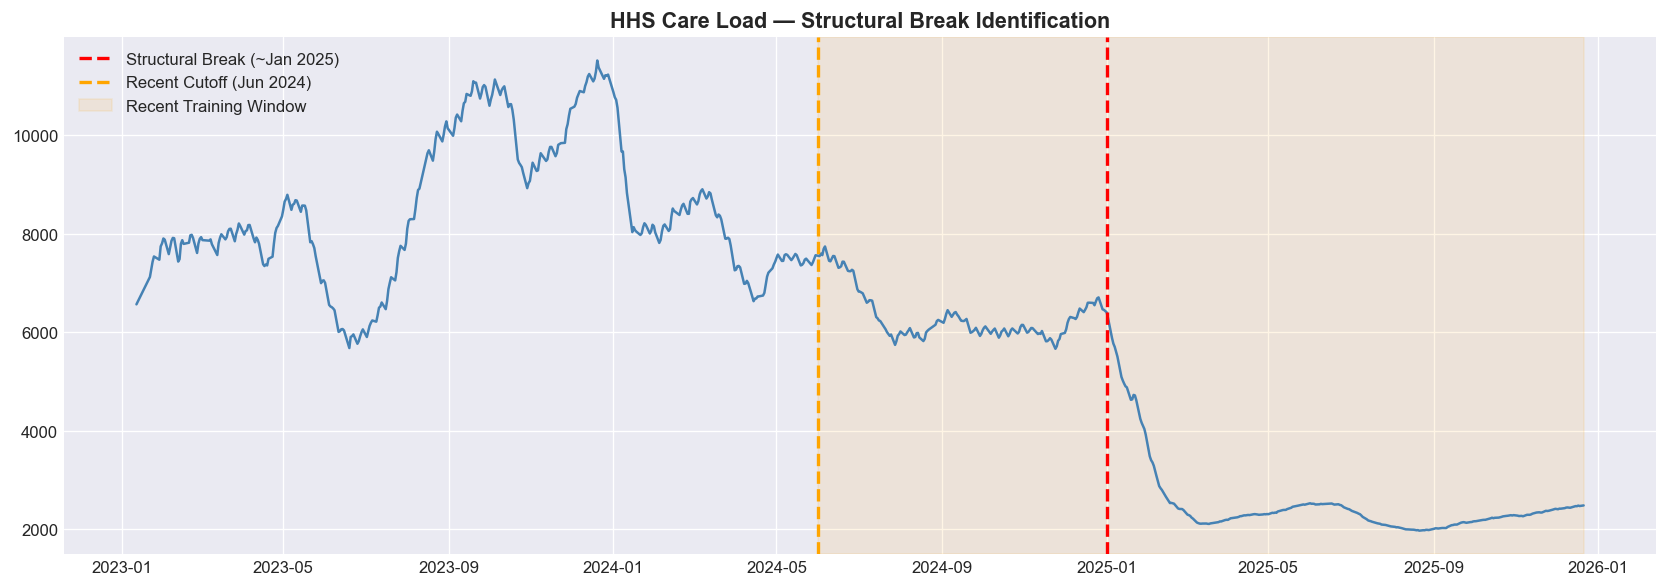

Structural Break Analysis:
  Pre-break mean  (before Jan 2025) : 7801
  Post-break mean (after Jan 2025)  : 2537
  Difference                        : 5264


In [30]:
# Visualize the structural break
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['hhs_care'], color='steelblue', linewidth=1.5)
plt.axvline(x=pd.Timestamp('2025-01-01'), color='red', 
            linestyle='--', linewidth=2, label='Structural Break (~Jan 2025)')
plt.axvline(x=pd.Timestamp('2024-06-01'), color='orange',
            linestyle='--', linewidth=2, label='Recent Cutoff (Jun 2024)')
plt.axvspan(pd.Timestamp('2024-06-01'), df.index.max(),
            alpha=0.1, color='orange', label='Recent Training Window')
plt.title('HHS Care Load — Structural Break Identification',
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/structural_break.png', bbox_inches='tight')
plt.show()

print("Structural Break Analysis:")
print(f"  Pre-break mean  (before Jan 2025) : {df[df.index < '2025-01-01']['hhs_care'].mean():.0f}")
print(f"  Post-break mean (after Jan 2025)  : {df[df.index >= '2025-01-01']['hhs_care'].mean():.0f}")
print(f"  Difference                        : {abs(df[df.index < '2025-01-01']['hhs_care'].mean() - df[df.index >= '2025-01-01']['hhs_care'].mean()):.0f}")

In [31]:
# Use full training data for statistical models
# Structural break is documented as a finding — not something to fix
train_recent = train.copy()

print(f"Training on full dataset")
print(f"Train size : {len(train_recent)} rows")
print(f"Train mean : {train_recent.mean():.0f}")
print(f"Test mean  : {test.mean():.0f}")
print(f"Mean gap   : {abs(train_recent.mean() - test.mean()):.0f}")
print()
print("Note: Large mean gap exists due to structural break in Jan 2025")
print("Statistical models are expected to struggle with this break")
print("This finding motivates escalation to ML models")

Training on full dataset
Train size : 967 rows
Train mean : 6487
Test mean  : 2267
Mean gap   : 4220

Note: Large mean gap exists due to structural break in Jan 2025
Statistical models are expected to struggle with this break
This finding motivates escalation to ML models


In [32]:
def evaluate_forecast(actual, predicted, model_name):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    
    mae  = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))
    mape = np.mean(np.abs((actual - predicted) / (actual + 1e-10))) * 100
    
    print(f"\n{'='*45}")
    print(f"  Model : {model_name}")
    print(f"{'='*45}")
    print(f"  MAE   : {mae:.2f}")
    print(f"  RMSE  : {rmse:.2f}")
    print(f"  MAPE  : {mape:.2f}%")
    print(f"{'='*45}")
    
    return {'Model': model_name, 'MAE': round(mae, 2),
            'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

In [33]:
# Stationary Test

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\nADF Test — {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical Values:")
    for key, val in result[4].items():
        print(f"    {key}: {val:.4f}")
    if result[1] <= 0.05:
        print(f"  Result: STATIONARY ✓ (p <= 0.05)")
    else:
        print(f"  Result: NON-STATIONARY ✗ (p > 0.05)")
    return result[1]

p_orig = adf_test(train_recent, 'Recent HHS Care (Original)')
p_diff = adf_test(train_recent.diff().dropna(), 'Recent HHS Care (First Difference)')

d_value = 0 if p_orig <= 0.05 else 1
print(f"\nSelected d value for ARIMA: {d_value}")


ADF Test — Recent HHS Care (Original)
  ADF Statistic : -1.1013
  p-value       : 0.7146
  Critical Values:
    1%: -3.4373
    5%: -2.8646
    10%: -2.5684
  Result: NON-STATIONARY ✗ (p > 0.05)

ADF Test — Recent HHS Care (First Difference)
  ADF Statistic : -4.8744
  p-value       : 0.0000
  Critical Values:
    1%: -3.4373
    5%: -2.8646
    10%: -2.5684
  Result: STATIONARY ✓ (p <= 0.05)

Selected d value for ARIMA: 1


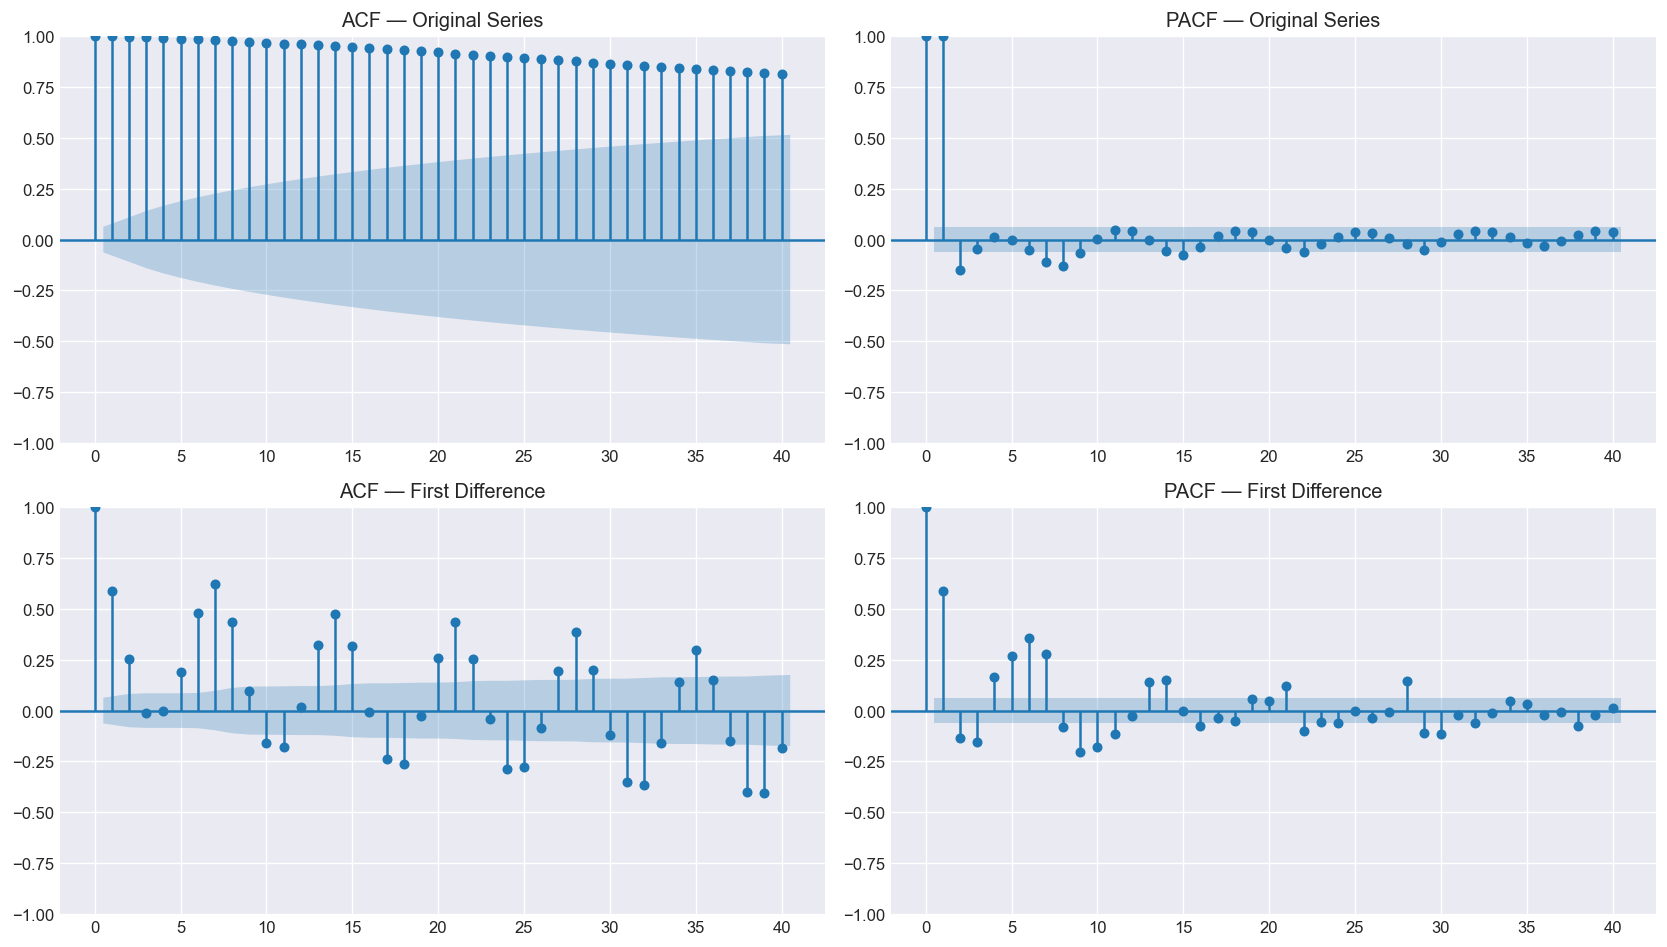

In [34]:
# ACF and PACF 

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original series
plot_acf(train.dropna(),  lags=40, ax=axes[0,0], 
         title='ACF — Original Series')
plot_pacf(train.dropna(), lags=40, ax=axes[0,1], 
          title='PACF — Original Series')

# First differenced series
train_diff = train.diff().dropna()
plot_acf(train_diff,  lags=40, ax=axes[1,0], 
         title='ACF — First Difference')
plot_pacf(train_diff, lags=40, ax=axes[1,1], 
          title='PACF — First Difference')

plt.tight_layout()
plt.savefig('../reports/figures/acf_pacf.png', bbox_inches='tight')
plt.show()

### Exponential Smoothing Model

Fitting Exponential Smoothing Model...
Using recent training data (Jun 2024 onwards)
---------------------------------------------

  Model : Exponential Smoothing
  MAE   : 86.69
  RMSE  : 97.40
  MAPE  : 3.74%


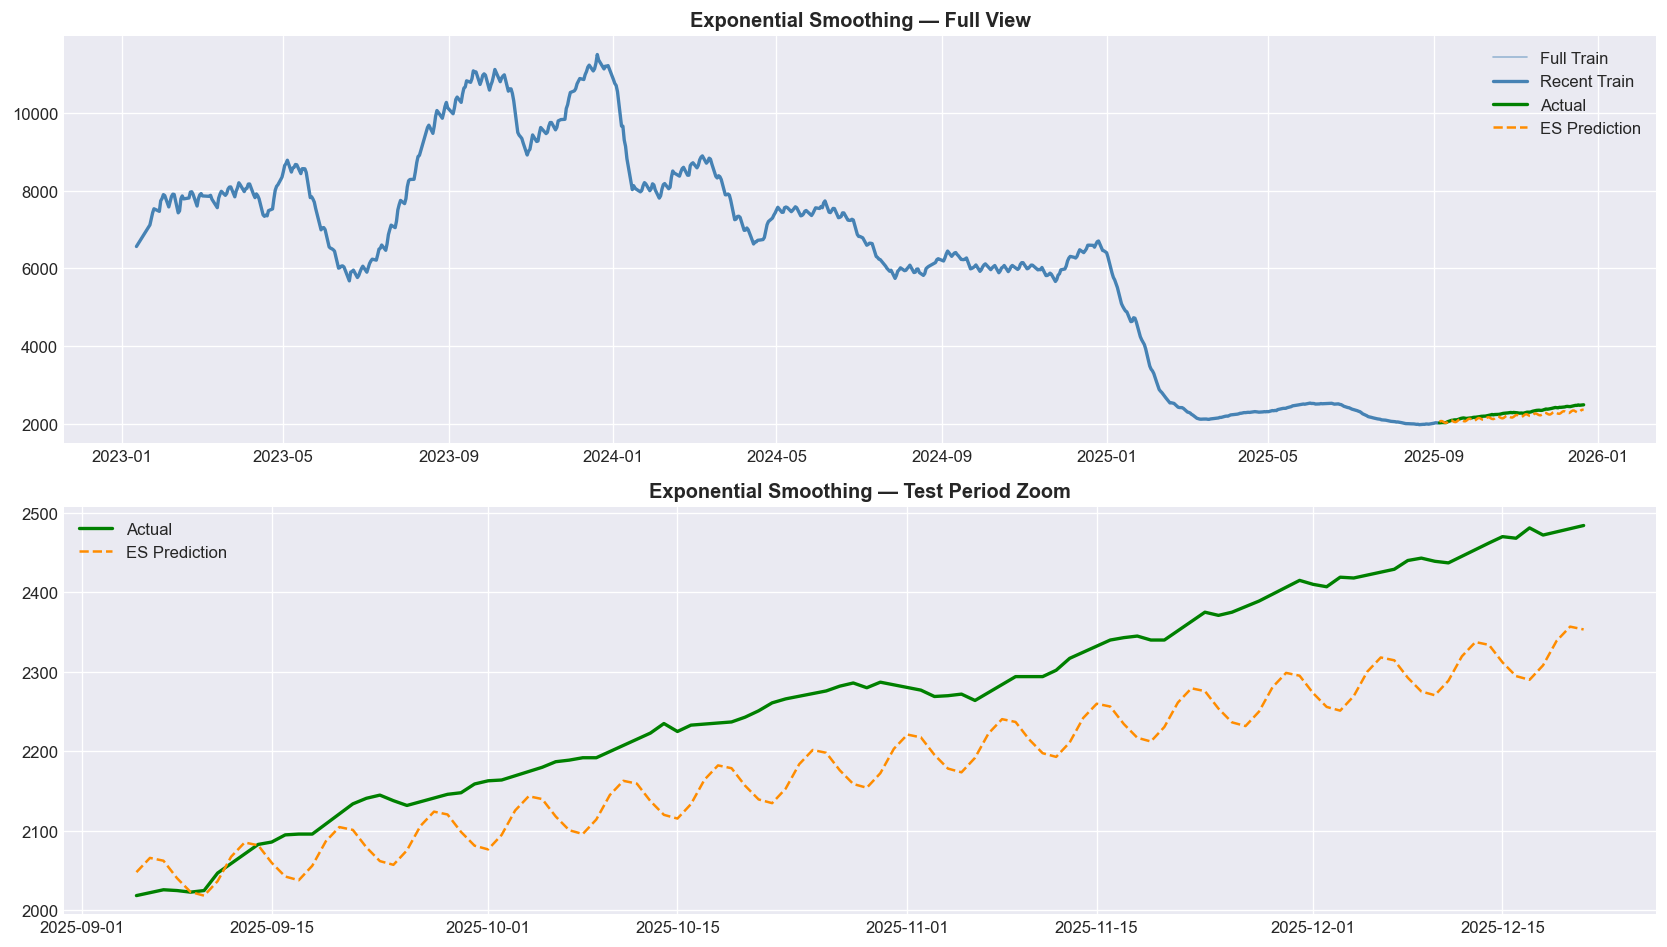

In [35]:


print("Fitting Exponential Smoothing Model...")
print("Using recent training data (Jun 2024 onwards)")
print("-" * 45)

es_model = ExponentialSmoothing(
    train_recent,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit(optimized=True)

es_predictions = es_model.forecast(len(test))
es_predictions.index = test.index

es_results = evaluate_forecast(test, es_predictions, 'Exponential Smoothing')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full picture
axes[0].plot(train.index, train.values,
             color='steelblue', linewidth=1, alpha=0.5, label='Full Train')
axes[0].plot(train_recent.index, train_recent.values,
             color='steelblue', linewidth=2, label='Recent Train')
axes[0].plot(test.index, test.values,
             color='green', linewidth=2, label='Actual')
axes[0].plot(test.index, es_predictions.values,
             color='darkorange', linewidth=1.5,
             linestyle='--', label='ES Prediction')
axes[0].set_title('Exponential Smoothing — Full View', fontweight='bold')
axes[0].legend()

# Zoomed test period
axes[1].plot(test.index, test.values,
             color='green', linewidth=2, label='Actual')
axes[1].plot(test.index, es_predictions.values,
             color='darkorange', linewidth=1.5,
             linestyle='--', label='ES Prediction')
axes[1].set_title('Exponential Smoothing — Test Period Zoom', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/es_forecast.png', bbox_inches='tight')
plt.show()

### ARIMA Grid Search

In [36]:
p_values = [1, 2, 3]
d_values = [d_value]
q_values = [1, 2, 3]

best_aic    = np.inf
best_params = None
arima_search_results = []

print("Searching for best ARIMA parameters...")
print(f"Using recent training data | d={d_value}")
print("-" * 45)

for p, d, q in product(p_values, d_values, q_values):
    try:
        model  = ARIMA(train_recent, order=(p, d, q))
        fitted = model.fit()
        aic    = fitted.aic
        arima_search_results.append({
            'p': p, 'd': d, 'q': q, 'AIC': round(aic, 2)
        })
        if aic < best_aic:
            best_aic    = aic
            best_params = (p, d, q)
        print(f"ARIMA({p},{d},{q}) — AIC: {aic:.2f}")
    except:
        pass

print(f"\nBest Parameters : ARIMA{best_params}")
print(f"Best AIC        : {best_aic:.2f}")

# Show search results as sorted table
search_df = pd.DataFrame(arima_search_results).sort_values('AIC')
print("\nAll Results Sorted by AIC:")
print(search_df.to_string(index=False))

Searching for best ARIMA parameters...
Using recent training data | d=1
---------------------------------------------
ARIMA(1,1,1) — AIC: 10873.55
ARIMA(1,1,2) — AIC: 10839.74
ARIMA(1,1,3) — AIC: 10818.78
ARIMA(2,1,1) — AIC: 10876.14
ARIMA(2,1,2) — AIC: 10790.62
ARIMA(2,1,3) — AIC: 10820.33
ARIMA(3,1,1) — AIC: 10839.53
ARIMA(3,1,2) — AIC: 10537.61
ARIMA(3,1,3) — AIC: 10433.08

Best Parameters : ARIMA(3, 1, 3)
Best AIC        : 10433.08

All Results Sorted by AIC:
 p  d  q      AIC
 3  1  3 10433.08
 3  1  2 10537.61
 2  1  2 10790.62
 1  1  3 10818.78
 2  1  3 10820.33
 3  1  1 10839.53
 1  1  2 10839.74
 1  1  1 10873.55
 2  1  1 10876.14


In [37]:
print(f"Fitting ARIMA{best_params} on recent training data...")

arima_model  = ARIMA(train_recent, order=best_params)
arima_fitted = arima_model.fit()

print(arima_fitted.summary())

Fitting ARIMA(3, 1, 3) on recent training data...
                               SARIMAX Results                                
Dep. Variable:               hhs_care   No. Observations:                  967
Model:                 ARIMA(3, 1, 3)   Log Likelihood               -5209.539
Date:                Fri, 06 Mar 2026   AIC                          10433.078
Time:                        22:42:17   BIC                          10467.191
Sample:                    01-12-2023   HQIC                         10446.065
                         - 09-04-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.2425      0.003    647.326      0.000       2.236       2.249
ar.L2         -2.2391      0.005   -470.675      0.000      -2.248      -2.230
ar


  Model : ARIMA(3, 1, 3)
  MAE   : 144.35
  RMSE  : 161.63
  MAPE  : 6.20%


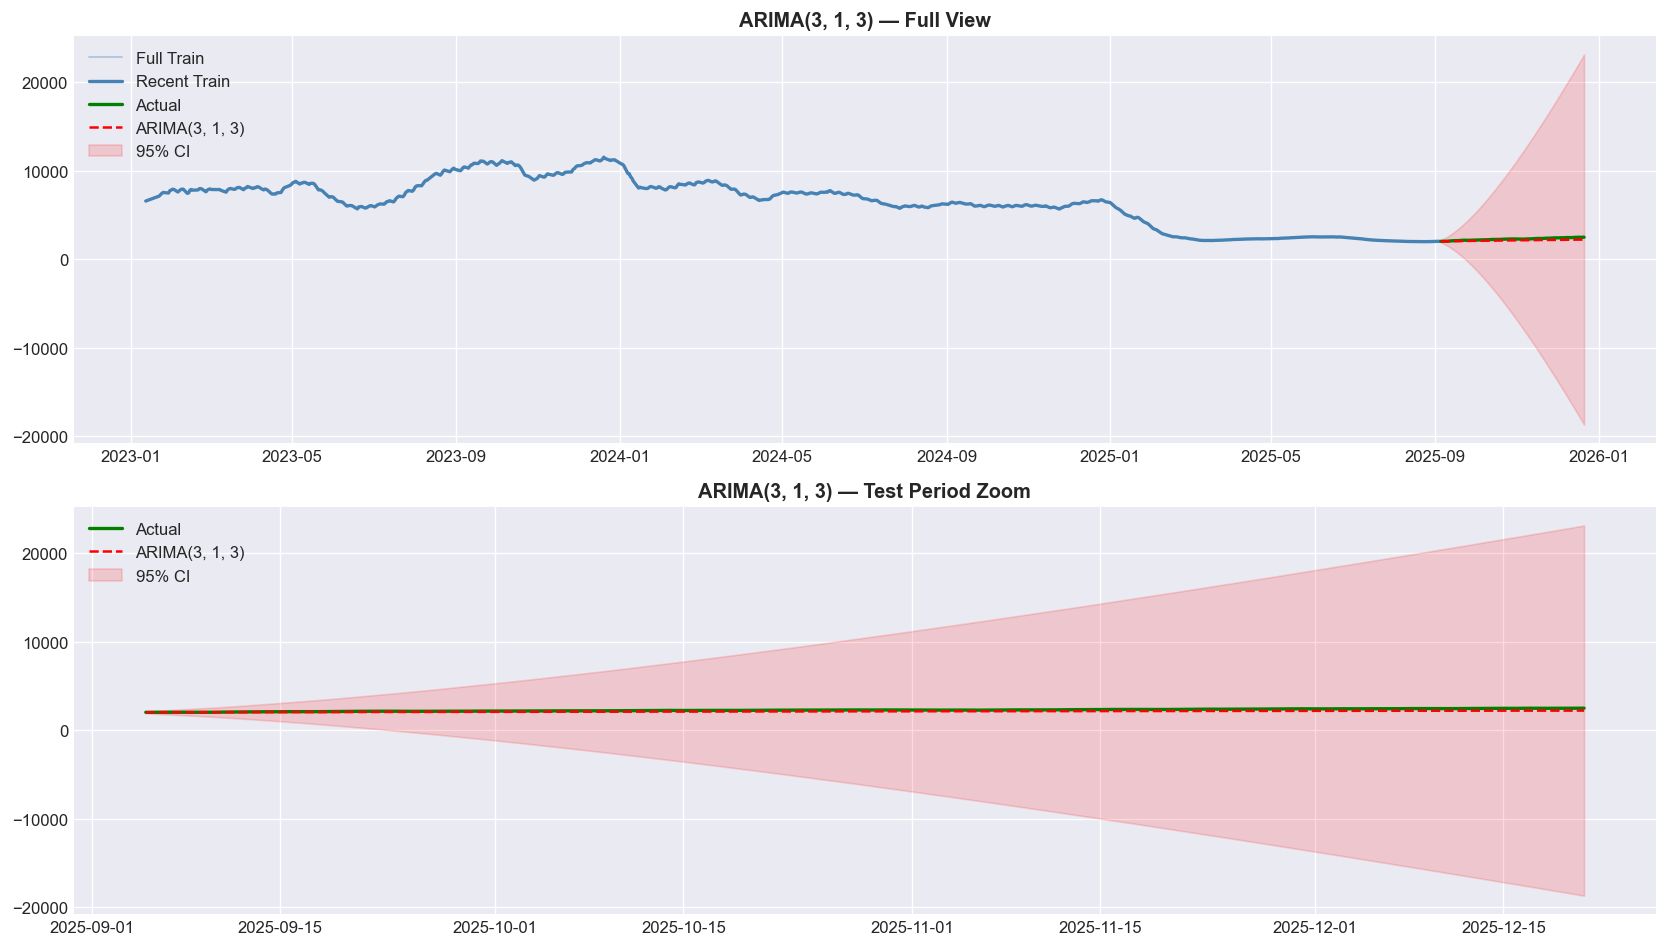

In [38]:
# ARIMA Forecasting

forecast_result    = arima_fitted.get_forecast(steps=len(test))
arima_predictions  = forecast_result.predicted_mean
arima_predictions.index = test.index

conf_int       = forecast_result.conf_int(alpha=0.05)
conf_int.index = test.index

arima_results = evaluate_forecast(test, arima_predictions, f'ARIMA{best_params}')

# Double plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full view
axes[0].plot(train.index, train.values,
             color='steelblue', linewidth=1, alpha=0.4, label='Full Train')
axes[0].plot(train_recent.index, train_recent.values,
             color='steelblue', linewidth=2, label='Recent Train')
axes[0].plot(test.index, test.values,
             color='green', linewidth=2, label='Actual')
axes[0].plot(test.index, arima_predictions.values,
             color='red', linewidth=1.5, linestyle='--',
             label=f'ARIMA{best_params}')
axes[0].fill_between(test.index,
                     conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                     alpha=0.15, color='red', label='95% CI')
axes[0].set_title(f'ARIMA{best_params} — Full View', fontweight='bold')
axes[0].legend()

# Zoomed test period
axes[1].plot(test.index, test.values,
             color='green', linewidth=2, label='Actual')
axes[1].plot(test.index, arima_predictions.values,
             color='red', linewidth=1.5, linestyle='--',
             label=f'ARIMA{best_params}')
axes[1].fill_between(test.index,
                     conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                     alpha=0.15, color='red', label='95% CI')
axes[1].set_title(f'ARIMA{best_params} — Test Period Zoom', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/arima_forecast.png', bbox_inches='tight')
plt.show()

### SARIMA Model

Fitting SARIMA model on recent training data...

  Model : SARIMA
  MAE   : 433.17
  RMSE  : 501.04
  MAPE  : 18.53%


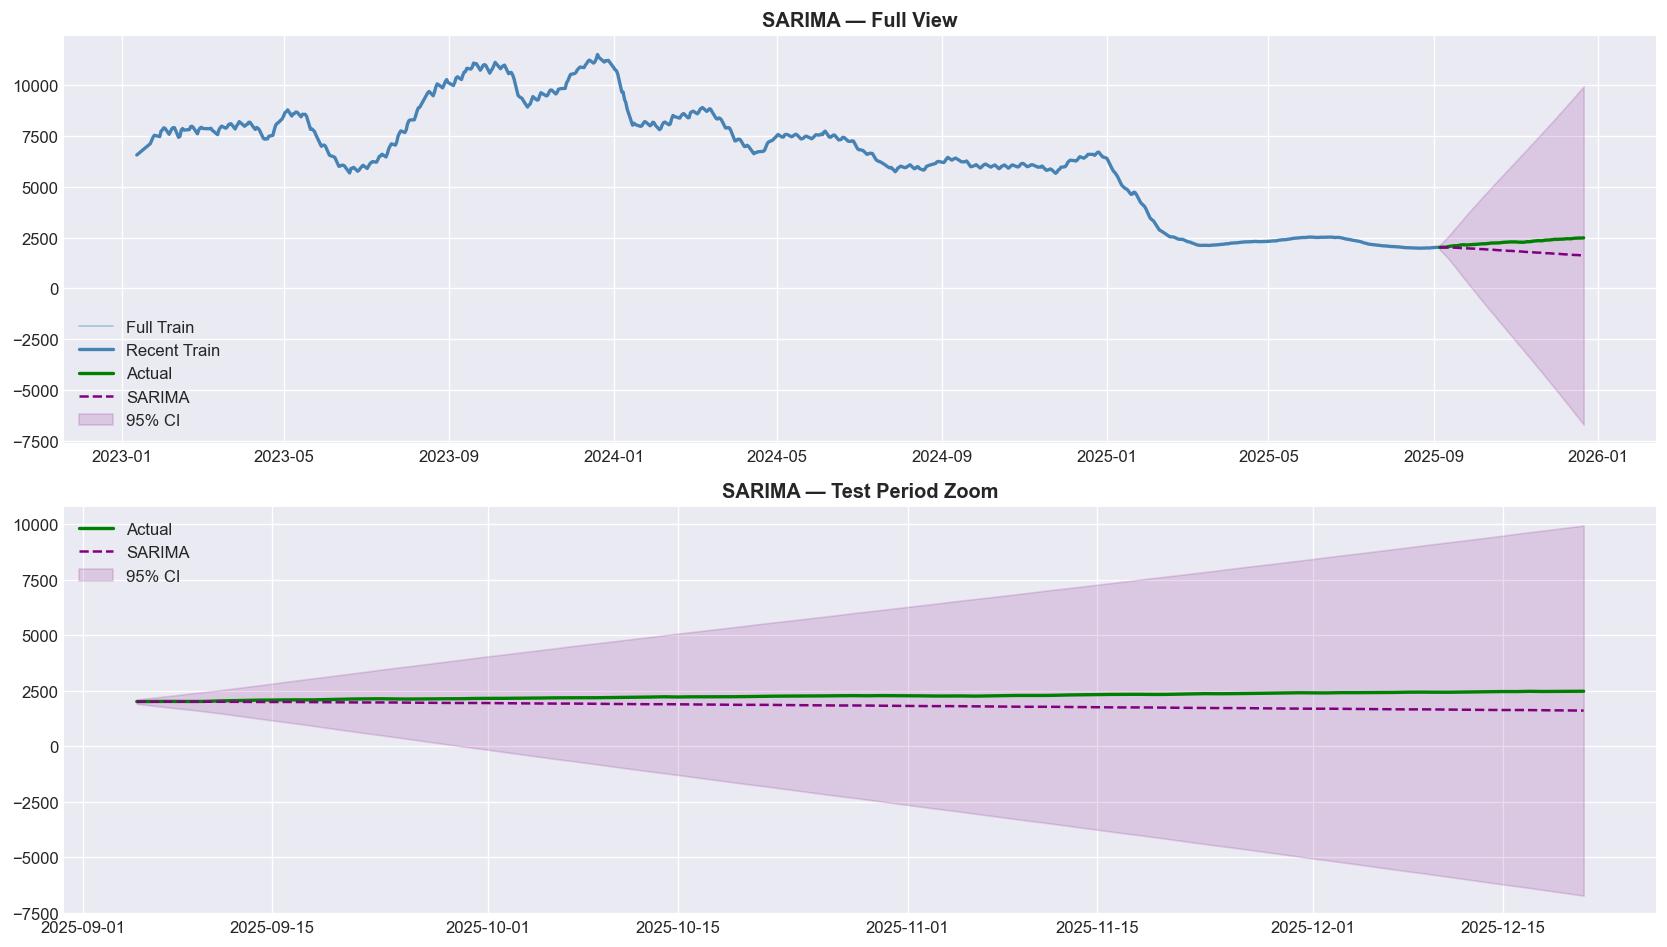

In [39]:
print("Fitting SARIMA model on recent training data...")

sarima_model = SARIMAX(
    train_recent,
    order=best_params,
    seasonal_order=(1, 1, 1, 7)
).fit(disp=False)

sarima_forecast    = sarima_model.get_forecast(steps=len(test))
sarima_predictions = sarima_forecast.predicted_mean
sarima_predictions.index = test.index

sarima_conf       = sarima_forecast.conf_int(alpha=0.05)
sarima_conf.index = test.index

sarima_results = evaluate_forecast(test, sarima_predictions, 'SARIMA')

# Double plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train.index, train.values,
             color='steelblue', linewidth=1, alpha=0.4, label='Full Train')
axes[0].plot(train_recent.index, train_recent.values,
             color='steelblue', linewidth=2, label='Recent Train')
axes[0].plot(test.index, test.values,
             color='green', linewidth=2, label='Actual')
axes[0].plot(test.index, sarima_predictions.values,
             color='purple', linewidth=1.5, linestyle='--', label='SARIMA')
axes[0].fill_between(test.index,
                     sarima_conf.iloc[:, 0], sarima_conf.iloc[:, 1],
                     alpha=0.15, color='purple', label='95% CI')
axes[0].set_title('SARIMA — Full View', fontweight='bold')
axes[0].legend()

axes[1].plot(test.index, test.values,
             color='green', linewidth=2, label='Actual')
axes[1].plot(test.index, sarima_predictions.values,
             color='purple', linewidth=1.5, linestyle='--', label='SARIMA')
axes[1].fill_between(test.index,
                     sarima_conf.iloc[:, 0], sarima_conf.iloc[:, 1],
                     alpha=0.15, color='purple', label='95% CI')
axes[1].set_title('SARIMA — Test Period Zoom', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/sarima_forecast.png', bbox_inches='tight')
plt.show()

  FULL COMPARISON — BASELINE + STATISTICAL MODELS
                              MAE    RMSE   MAPE
Model                                           
Naive Persistence            6.06    7.24   0.27
Moving Average (window=3)    9.76   11.77   0.43
Exponential Smoothing       86.69   97.40   3.74
ARIMA(3, 1, 3)             144.35  161.63   6.20
SARIMA                     433.17  501.04  18.53

Baseline floor (Naive) — MAE: 6.06

No statistical model beat the naive baseline.
This motivates escalation to ML models.


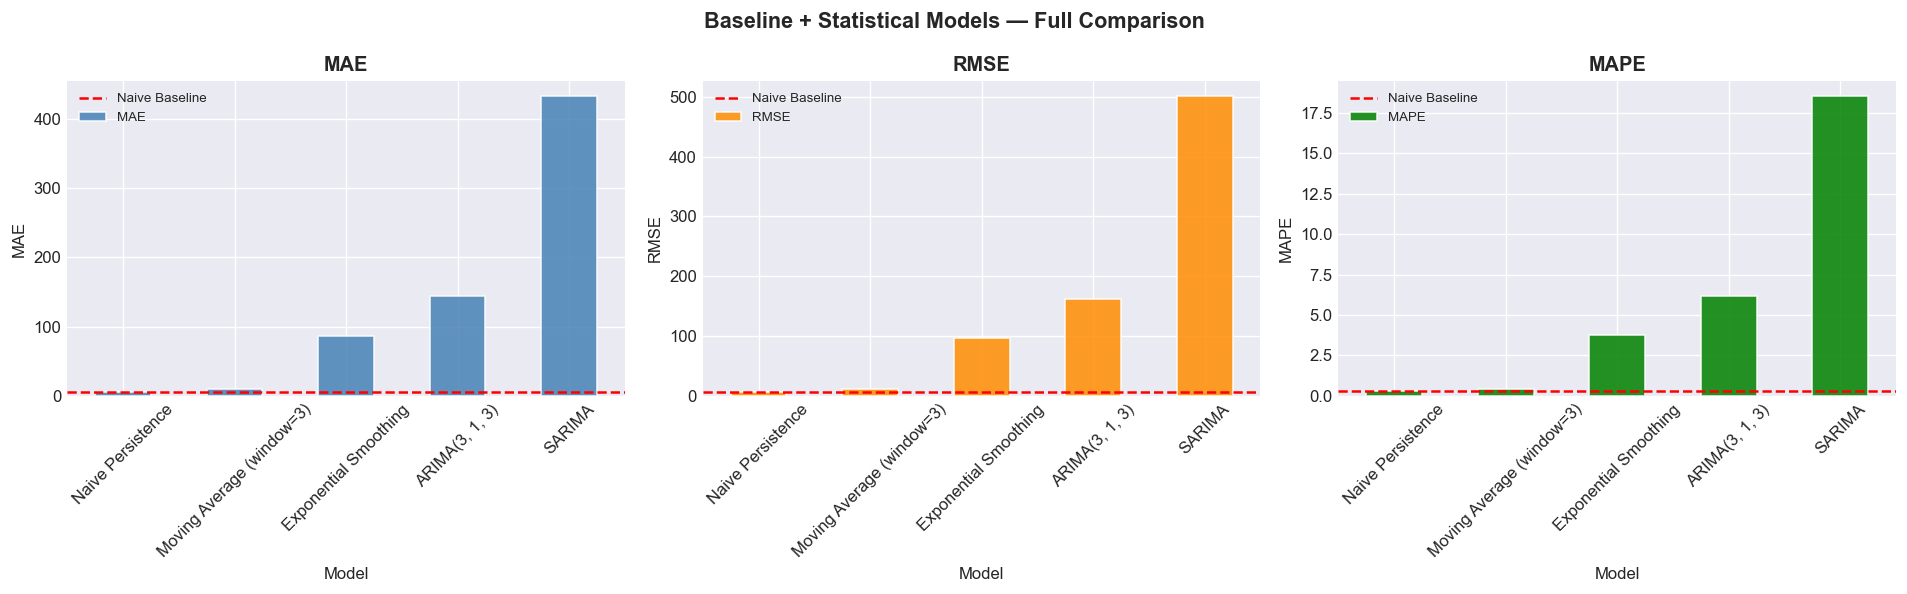

In [40]:
# Statistical Model Comparison

all_statistical_results = [es_results, arima_results, sarima_results]
results_df = pd.DataFrame(all_statistical_results).set_index('Model').round(2)

baseline_df  = pd.read_csv('../models/baseline_results.csv', index_col='Model')
full_comparison = pd.concat([baseline_df, results_df])

print("="*55)
print("  FULL COMPARISON — BASELINE + STATISTICAL MODELS")
print("="*55)
print(full_comparison.to_string())
print()
print(f"Baseline floor (Naive) — MAE: {baseline_df['MAE'].min():.2f}")
print()

beaten = results_df[results_df['MAE'] < baseline_df['MAE'].min()]
if len(beaten) > 0:
    print(f"Models that beat the baseline:")
    print(beaten)
else:
    print("No statistical model beat the naive baseline.")
    print("This motivates escalation to ML models.")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'MAPE']
colors  = ['steelblue', 'darkorange', 'green']

for ax, metric, color in zip(axes, metrics, colors):
    bars = full_comparison[metric].plot(kind='bar', ax=ax,
                                        color=color, edgecolor='white',
                                        alpha=0.85)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=baseline_df[metric].min(),
               color='red', linestyle='--',
               linewidth=1.5, label='Naive Baseline')
    ax.legend(fontsize=8)

plt.suptitle('Baseline + Statistical Models — Full Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/statistical_comparison.png', bbox_inches='tight')
plt.show()

In [41]:
results_df.to_csv('../models/statistical_results.csv')
print("Statistical model results saved.")
print()

print("  PERFORMANCE SUMMARY SO FAR")

print(full_comparison.to_string())
print()
print(f"Best MAE so far  : {full_comparison['MAE'].min():.2f} ({full_comparison['MAE'].idxmin()})")
print(f"Best RMSE so far : {full_comparison['RMSE'].min():.2f} ({full_comparison['RMSE'].idxmin()})")
print(f"Best MAPE so far : {full_comparison['MAPE'].min():.2f}% ({full_comparison['MAPE'].idxmin()})")
print()
print("Next: ML Models (Linear, Ridge, Random Forest, XGBoost)")

Statistical model results saved.

  PERFORMANCE SUMMARY SO FAR
                              MAE    RMSE   MAPE
Model                                           
Naive Persistence            6.06    7.24   0.27
Moving Average (window=3)    9.76   11.77   0.43
Exponential Smoothing       86.69   97.40   3.74
ARIMA(3, 1, 3)             144.35  161.63   6.20
SARIMA                     433.17  501.04  18.53

Best MAE so far  : 6.06 (Naive Persistence)
Best RMSE so far : 7.24 (Naive Persistence)
Best MAPE so far : 0.27% (Naive Persistence)

Next: ML Models (Linear, Ridge, Random Forest, XGBoost)
